<a href="https://colab.research.google.com/github/yanhemis/P-S-paper/blob/heewon/Morphology_(0_03).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

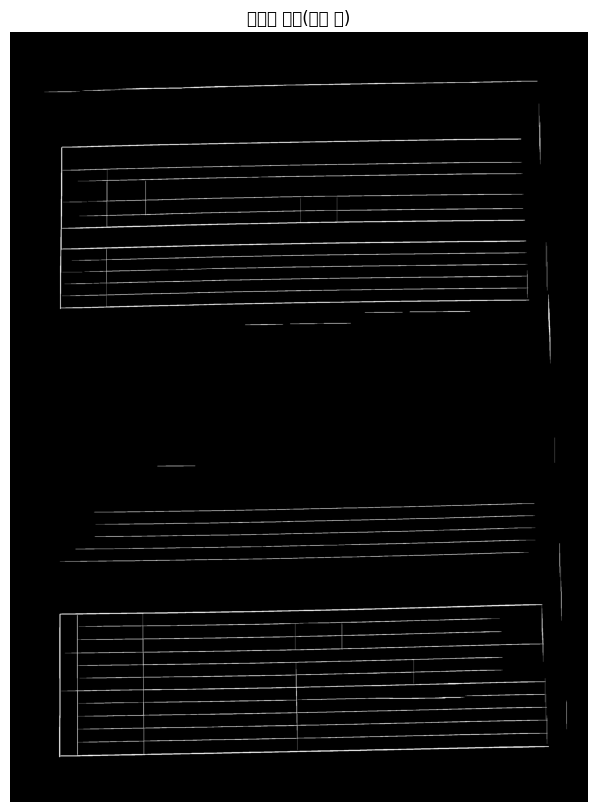

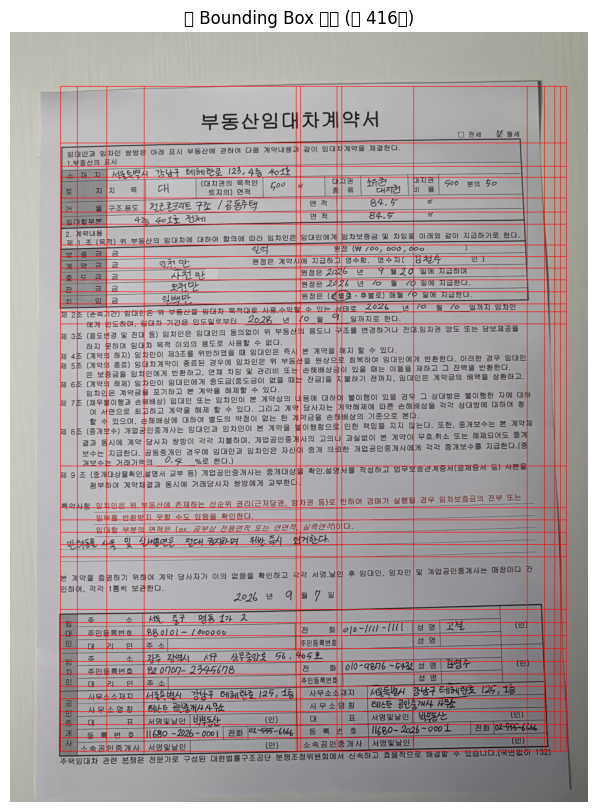

이미지 크기: 3000 x 4000
검출된 행 개수: 32, 열 개수: 13
검출된 셀 개수: 416
병합 셀 후보 개수: 416
병합 셀 상세: [{'row': 0, 'col': 0, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 1, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 2, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 3, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 4, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 5, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 6, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 7, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 8, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 9, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 10, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 11, 'missing_right': True, 'missing_bottom': True}, {'row': 0, 'col': 12, 'missing_right': True, 'missing_bottom': True}, {'row': 1, 'col':

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image

# ------------------------------------------------------------
# 0. 유틸 함수
# ------------------------------------------------------------
def show(img, title="", cmap=None):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def load_image(path):
    # cv2로 먼저 시도, 실패하면(jpg 등 비표준 포맷) PIL로 변환해서 재시도
    img = cv2.imread(path)
    if img is None:
        pil_img = Image.open(path).convert("RGB")
        img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray

# ------------------------------------------------------------
# 1. 전처리 + 흐린 선 대비 강화
# ------------------------------------------------------------
def enhance_and_binarize(gray):
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    bin_img = cv2.adaptiveThreshold(
        enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 15, 10
    )
    return bin_img

# ------------------------------------------------------------
# 2. 수평/수직 선 추출 + 끊어진 선 보정
# ------------------------------------------------------------
def extract_hv_lines(bin_img, img_w, img_h, h_ratio=0.4, v_ratio=0.4):
    h_len = max(10, int(img_w * h_ratio))
    v_len = max(10, int(img_h * v_ratio))
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (h_len, 1))
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, v_len))
    h_lines = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, h_kernel, iterations=1)
    v_lines = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, v_kernel, iterations=1)
    return h_lines, v_lines

def close_gaps(h_lines, v_lines, img_w, img_h, close_ratio=0.02):
    close_len = max(5, int(img_w * close_ratio))
    h_close = cv2.getStructuringElement(cv2.MORPH_RECT, (close_len, 1))
    v_close = cv2.getStructuringElement(cv2.MORPH_RECT, (1, close_len))
    h_out = cv2.morphologyEx(h_lines, cv2.MORPH_CLOSE, h_close)
    v_out = cv2.morphologyEx(v_lines, cv2.MORPH_CLOSE, v_close)
    return h_out, v_out

# ------------------------------------------------------------
# 3. 문자 획('ㅣ','ㅡ') 오검출 제거
# ------------------------------------------------------------
def filter_short_components(mask, axis, min_len):
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for i in range(1, n):
        length = stats[i, cv2.CC_STAT_WIDTH] if axis == 'h' else stats[i, cv2.CC_STAT_HEIGHT]
        if length >= min_len:
            clean[labels == i] = 255
    return clean

# ------------------------------------------------------------
# 4. grid 좌표 추출 + 병합 셀 판정
# ------------------------------------------------------------
def cluster_positions(mask, axis, gap_thresh=10):
    proj = np.sum(mask, axis=1 if axis == 'h' else 0)
    idx = np.where(proj > 0)[0]
    if len(idx) == 0:
        return []
    clusters, start, prev = [], idx[0], idx[0]
    for i in idx[1:]:
        if i - prev > gap_thresh:
            clusters.append((start + prev) // 2)
            start = i
        prev = i
    clusters.append((start + prev) // 2)
    return sorted(clusters)

def detect_merged_cells(h_lines, v_lines, rows, cols, presence_ratio=0.5):
    merged = []
    for i in range(len(rows) - 1):
        for j in range(len(cols) - 1):
            y1, y2 = rows[i], rows[i + 1]
            x1, x2 = cols[j], cols[j + 1]
            right = v_lines[y1:y2, max(0, cols[j+1]-2):cols[j+1]+2]
            bottom = h_lines[max(0, rows[i+1]-2):rows[i+1]+2, x1:x2]
            right_ok = right.size > 0 and np.mean(right > 0) > presence_ratio
            bottom_ok = bottom.size > 0 and np.mean(bottom > 0) > presence_ratio
            if not right_ok or not bottom_ok:
                merged.append({"row": i, "col": j,
                                "missing_right": not right_ok,
                                "missing_bottom": not bottom_ok})
    return merged

# ------------------------------------------------------------
# 5. 셀 Bounding Box 생성
# ------------------------------------------------------------
def get_cell_boxes_from_grid(rows, cols):
    boxes = []
    for i in range(len(rows) - 1):
        for j in range(len(cols) - 1):
            x1, y1, x2, y2 = cols[j], rows[i], cols[j + 1], rows[i + 1]
            boxes.append((x1, y1, x2 - x1, y2 - y1))
    return boxes

def draw_boxes(img, boxes, color=(0, 0, 255)):
    out = img.copy()
    for (x, y, w, h) in boxes:
        cv2.rectangle(out, (x, y), (x + w, y + h), color, 2)
    return out

# ==============================================================
# 실행: sample.jpg 1장으로 전체 파이프라인 테스트
# ==============================================================
t0 = time.time()

# 1) 이미지 로드
img, gray = load_image("/content/sample.jpg")
img_h, img_w = gray.shape

# 2) 전처리 + 이진화
bin_img = enhance_and_binarize(gray)

# 3) 선 추출 + 끊어진 선 보정
h_lines, v_lines = extract_hv_lines(
    bin_img, img_w, img_h,
    h_ratio=0.03,
    v_ratio=0.03
)
h_lines, v_lines = close_gaps(h_lines, v_lines, img_w, img_h)

# 4) 문자 오검출 제거
h_clean = filter_short_components(h_lines, 'h', img_w * 0.03)
v_clean = filter_short_components(v_lines, 'v', img_h * 0.03)

# 5) grid 좌표 + 병합 셀 판정
rows = cluster_positions(h_clean, 'h')
cols = cluster_positions(v_clean, 'v')
merged_cells = detect_merged_cells(h_clean, v_clean, rows, cols)

# 6) 셀 Bounding Box 생성
cell_boxes = get_cell_boxes_from_grid(rows, cols)
result_img = draw_boxes(img, cell_boxes)

elapsed = time.time() - t0

# ------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------
show(cv2.bitwise_or(h_clean, v_clean), title="검출된 표선(정제 후)", cmap='gray')
show(result_img, title=f"셀 Bounding Box 결과 (총 {len(cell_boxes)}개)")

print(f"이미지 크기: {img_w} x {img_h}")
print(f"검출된 행 개수: {len(rows)-1 if rows else 0}, 열 개수: {len(cols)-1 if cols else 0}")
print(f"검출된 셀 개수: {len(cell_boxes)}")
print(f"병합 셀 후보 개수: {len(merged_cells)}")
if merged_cells:
    print("병합 셀 상세:", merged_cells)
print(f"처리 시간: {elapsed:.3f}초")

In [ ]:
pred_boxes = []

for x, y, w, h in cell_boxes:
    pred_boxes.append([
        int(x),
        int(y),
        int(x + w),
        int(y + h)
    ])

print(f"✅ Morphology 0.03 예측 bbox: {len(pred_boxes)}개")

✅ Morphology 0.03 예측 bbox: 416개


In [ ]:
with open("gt_sample.json", "r", encoding="utf-8") as f:
    gt_data = json.load(f)

for threshold in [0.3, 0.5, 0.7]:
    evaluate_model(
        gt_data,
        pred_boxes,
        threshold
    )

Morphology 평가 결과 (IoU ≥ 0.3)

[GENERAL]
TP: 3
FP: 13
FN: 2
Precision: 18.8%
Recall:    60.0%
F1:        28.6%

[MERGED]
TP: 2
FP: 71
FN: 3
Precision: 2.7%
Recall:    40.0%
F1:        5.1%

BACKGROUND FP: 327개
Morphology 평가 결과 (IoU ≥ 0.5)

[GENERAL]
TP: 1
FP: 15
FN: 4
Precision: 6.2%
Recall:    20.0%
F1:        9.5%

[MERGED]
TP: 0
FP: 73
FN: 5
Precision: 0.0%
Recall:    0.0%
F1:        0.0%

BACKGROUND FP: 327개
Morphology 평가 결과 (IoU ≥ 0.7)

[GENERAL]
TP: 1
FP: 15
FN: 4
Precision: 6.2%
Recall:    20.0%
F1:        9.5%

[MERGED]
TP: 0
FP: 73
FN: 5
Precision: 0.0%
Recall:    0.0%
F1:        0.0%

BACKGROUND FP: 327개
